Starting volatility surface calculation, please wait...


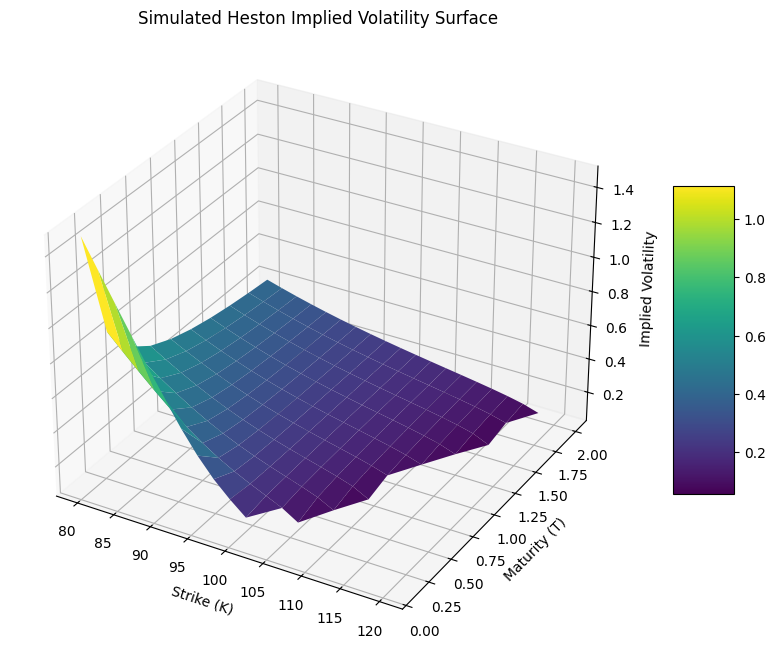

Calculation complete!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Ensure the notebook can find the code in the src directory
sys.path.append('../src')
from heston_pricer import HestonPricer, implied_volatility

# 1. Set typical Heston parameters to depict a clear Volatility Smile (left-skewed)
pricer = HestonPricer(kappa=2.0, theta=0.04, sigma=0.3, rho=-0.7, v0=0.04, r=0.02)
S0 = 100.0

# 2. Define the grid for strike price (K) and maturity (T)
strikes = np.linspace(80, 120, 20)
maturities = np.linspace(0.1, 2.0, 10)
K_grid, T_grid = np.meshgrid(strikes, maturities)
IV_surface = np.zeros_like(K_grid)

# 3. Loop to calculate pricing and solve for IV
print("Starting volatility surface calculation, please wait...")
for i in range(len(maturities)):
    for j in range(len(strikes)):
        price = pricer.price_european_call(S0, K_grid[i,j], T_grid[i,j])
        IV_surface[i,j] = implied_volatility(price, S0, K_grid[i,j], T_grid[i,j], r=0.02)

# 4. Plot the 3D volatility surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(K_grid, T_grid, IV_surface, cmap='viridis', edgecolor='none')
ax.set_xlabel('Strike (K)')
ax.set_ylabel('Maturity (T)')
ax.set_zlabel('Implied Volatility')
ax.set_title('Simulated Heston Implied Volatility Surface')
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()
print("Calculation complete!")